In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Análise por Cenário Individual + Agregado (P95 e Taxa de Falhas %)

In [28]:
dados_path = Path("dados")

_cenarios_arquivos = {
    "100kb": "100KB",
    "400kb": "400KB",
    "900kb": "900KB",
    "todos": "Todos",
}

_containers = [1, 2, 3]
_usuarios = [100, 400, 650]

_registros = []

for prefixo_arquivo, nome_cenario in _cenarios_arquivos.items():
    for cont in _containers:
        for users in _usuarios:
            arquivo = f"{prefixo_arquivo}_{cont}cont_{users}users.csv"
            caminho = dados_path / arquivo

            if caminho.exists():
                df = pd.read_csv(caminho)

                linha = df[df["Name"] == "Aggregated"]

                if not linha.empty:
                    row = linha.iloc[0]

                    req = row["Request Count"]
                    fail = row["Failure Count"]

                    _registros.append({
                        "cenario": nome_cenario,
                        "containers": cont,
                        "usuarios": users,
                        "arquivo": arquivo,
                        "p95": row["95%"],
                        "tempo_medio": row["Average Response Time"],
                        "rps": row["Requests/s"],
                        "falhas": fail,
                        "taxa_falhas_pct": (fail / req * 100) if req > 0 else 0,
                    })
            else:
                print(f"Arquivo não encontrado: {arquivo}")

df_todos_cenarios = pd.DataFrame(_registros)

df_todos_cenarios

,cenario,containers,usuarios,arquivo,p95,tempo_medio,rps,falhas,taxa_falhas_pct
0,100KB,1,100,100kb_1cont_100users.csv,350,160.117134,47.224050,0,0.000000
1,100KB,1,400,100kb_1cont_400users.csv,900,417.803808,165.905352,0,0.000000
2,100KB,1,650,100kb_1cont_650users.csv,3200,1790.088706,172.197862,211,1.462029
3,100KB,2,100,100kb_2cont_100users.csv,340,146.341808,47.345971,0,0.000000
4,100KB,2,400,100kb_2cont_400users.csv,810,401.416792,167.841453,0,0.000000
5,100KB,2,650,100kb_2cont_650users.csv,1700,623.986215,248.969622,3155,26.778136
6,100KB,3,100,100kb_3cont_100users.csv,300,173.390319,46.718549,0,0.000000
7,100KB,3,400,100kb_3cont_400users.csv,890,358.672801,170.216992,0,0.000000
8,100KB,3,650,100kb_3cont_650users.csv,1900,516.113977,257.624108,12039,36.651749
9,400KB,1,100,400kb_1cont_100users.csv,280,156.804057,46.674904,0,0.000000


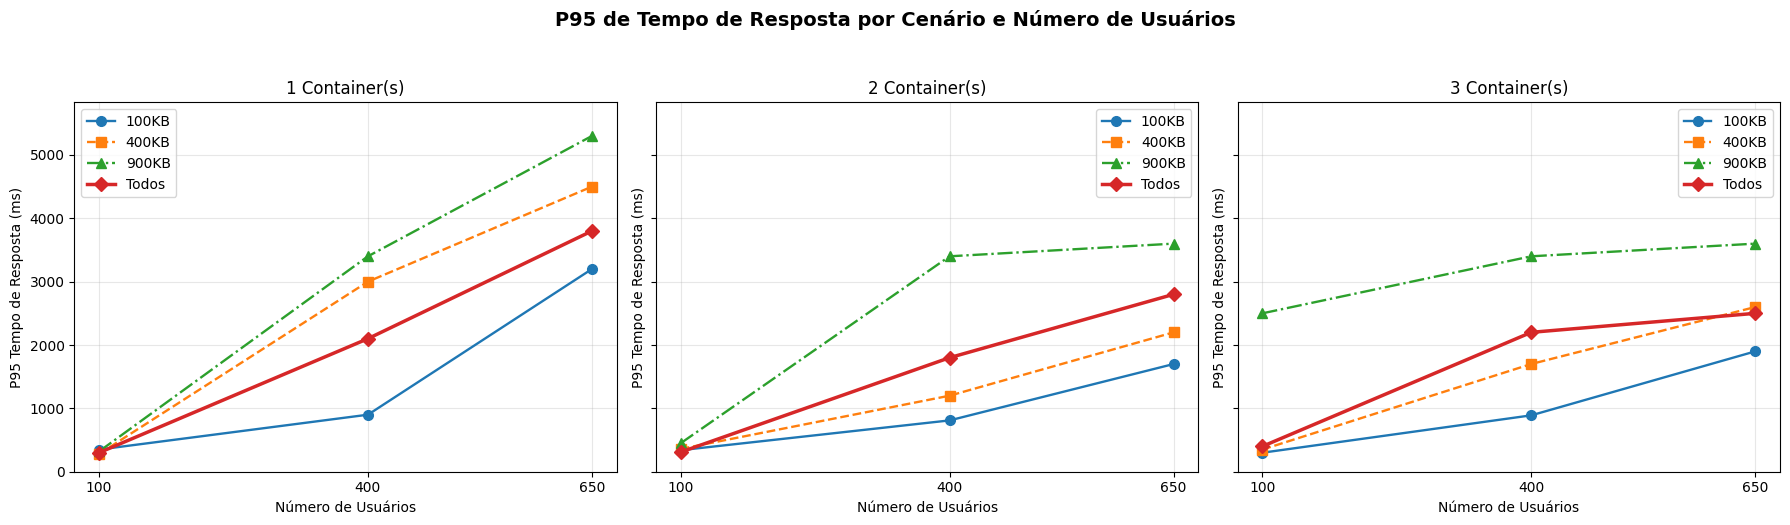

In [29]:
import matplotlib.pyplot as plt

_ordem_cenarios = ["100KB", "400KB", "900KB", "Todos"]

_cores = {
    "100KB": "tab:blue",
    "400KB": "tab:orange",
    "900KB": "tab:green",
    "Todos": "tab:red",
}

_estilos = {
    "100KB": "o-",
    "400KB": "s--",
    "900KB": "^-.",
    "Todos": "D-",
}

_y_max = df_todos_cenarios["p95"].max()

_y_limite = _y_max * 1.10

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

fig.suptitle(
    "P95 de Tempo de Resposta por Cenário e Número de Usuários",
    fontsize=14,
    fontweight="bold",
    y=1.04
)

for i, cont in enumerate(_containers):
    ax = axes[i]

    df_cont = df_todos_cenarios[
        df_todos_cenarios["containers"] == cont
    ]

    for cenario in _ordem_cenarios:
        df_plot = df_cont[
            df_cont["cenario"] == cenario
        ].sort_values("usuarios")

        if not df_plot.empty:
            ax.plot(
                df_plot["usuarios"],
                df_plot["p95"],
                _estilos[cenario],
                color=_cores[cenario],
                label=cenario,
                linewidth=2.5 if cenario == "Todos" else 1.7,
                markersize=7
            )

    ax.set_title(f"{cont} Container(s)")
    ax.set_xlabel("Número de Usuários")
    ax.set_ylabel("P95 Tempo de Resposta (ms)")
    ax.set_xticks(_usuarios)
    ax.set_ylim(0, _y_limite)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

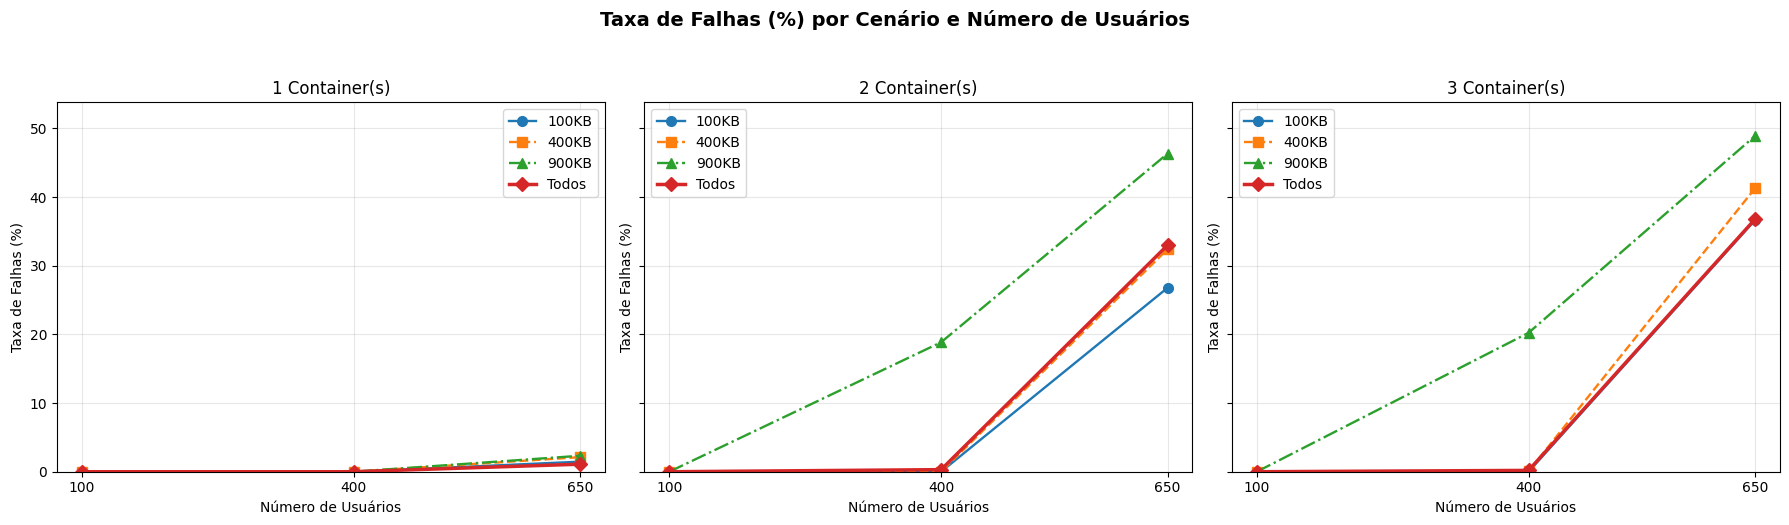

In [30]:
import matplotlib.pyplot as plt

_ordem_cenarios = ["100KB", "400KB", "900KB", "Todos"]

_cores = {
    "100KB": "tab:blue",
    "400KB": "tab:orange",
    "900KB": "tab:green",
    "Todos": "tab:red",
}

_estilos = {
    "100KB": "o-",
    "400KB": "s--",
    "900KB": "^-.",
    "Todos": "D-",
}

_y_max = df_todos_cenarios["taxa_falhas_pct"].max()

_y_limite = _y_max * 1.10 if _y_max > 0 else 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

fig.suptitle(
    "Taxa de Falhas (%) por Cenário e Número de Usuários",
    fontsize=14,
    fontweight="bold",
    y=1.04
)

for i, cont in enumerate(_containers):
    ax = axes[i]

    df_cont = df_todos_cenarios[
        df_todos_cenarios["containers"] == cont
    ]

    for cenario in _ordem_cenarios:
        df_plot = df_cont[
            df_cont["cenario"] == cenario
        ].sort_values("usuarios")

        if not df_plot.empty:
            ax.plot(
                df_plot["usuarios"],
                df_plot["taxa_falhas_pct"],
                _estilos[cenario],
                color=_cores[cenario],
                label=cenario,
                linewidth=2.5 if cenario == "Todos" else 1.7,
                markersize=7
            )

    ax.set_title(f"{cont} Container(s)")
    ax.set_xlabel("Número de Usuários")
    ax.set_ylabel("Taxa de Falhas (%)")
    ax.set_xticks(_usuarios)
    ax.set_ylim(0, _y_limite)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Interpretação dos Resultados

### P95 de Tempo de Resposta

A análise do P95 mostra que o tempo de resposta aumenta conforme o número de usuários cresce. Esse comportamento é esperado, pois o aumento de usuários simultâneos gera maior concorrência por recursos do sistema.

Nos testes com **1 container**, o crescimento do P95 foi mais acentuado. Para 650 usuários, os cenários chegaram aproximadamente a:

| Cenário | P95 aproximado |
|---|---:|
| 100KB | 3.200 ms |
| 400KB | 4.500 ms |
| 900KB | 5.300 ms |
| Todos | 3.800 ms |

O cenário de **900KB** apresentou o pior desempenho, indicando que payloads maiores aumentam significativamente o tempo de resposta. O cenário de **400KB** também apresentou crescimento relevante, ficando acima do cenário agregado em alguns pontos.

Com **2 containers**, houve redução do P95 em comparação com 1 container, principalmente nas cargas de 400 e 650 usuários. Para 650 usuários, os valores ficaram aproximadamente entre **1.700 ms e 3.600 ms**, dependendo do cenário. Isso indica que a adição de um segundo container ajudou a distribuir parte da carga e reduziu a latência em relação à configuração com apenas 1 container.

Com **3 containers**, os resultados também foram melhores do que com 1 container em vários cenários, mas não houve ganho proporcional em relação a 2 containers. Em 650 usuários, os valores ficaram próximos dos obtidos com 2 containers em alguns casos. Isso sugere que adicionar mais containers no mesmo ambiente não garante necessariamente uma redução linear no tempo de resposta.

Um ponto de atenção é o cenário de **900KB com 3 containers e 100 usuários**, que já apresentou P95 elevado, próximo de **2.500 ms**. Esse valor foge do comportamento esperado para baixa carga e pode indicar uma instabilidade pontual no teste, contenção de recursos ou alguma variação específica do ambiente durante a execução.

De forma geral, o P95 mostra que:

- O aumento do número de usuários eleva o tempo de resposta.
- O cenário de **900KB** é o mais pesado em termos de latência.
- Usar 2 ou 3 containers reduz o P95 em relação a 1 container, principalmente sob maior carga.
- A configuração com 3 containers não apresentou ganho claramente superior à de 2 containers.

---

### Taxa de Falhas (%)

A taxa de falhas apresenta um comportamento importante para complementar a análise do P95. Embora mais containers tenham reduzido a latência em alguns cenários, isso não significou necessariamente maior confiabilidade.

Com **1 container**, a taxa de falhas permaneceu praticamente nula até 400 usuários. Mesmo em 650 usuários, as falhas ficaram baixas, próximas de **1% a 2%** dependendo do cenário. Isso indica que, apesar do aumento do tempo de resposta, o sistema ainda conseguiu responder à maior parte das requisições.

Com **2 containers**, a taxa de falhas aumentou bastante em 650 usuários. Os valores aproximados foram:

| Cenário | Taxa de falhas aproximada |
|---|---:|
| 100KB | 27% |
| 400KB | 33% |
| 900KB | 46% |
| Todos | 33% |

Esse resultado mostra que a configuração com 2 containers reduziu o P95 em alguns casos, mas passou a apresentar uma quantidade significativa de falhas sob carga alta.

Com **3 containers**, a situação também foi crítica em 650 usuários, especialmente nos cenários de maior payload:

| Cenário | Taxa de falhas aproximada |
|---|---:|
| 100KB | baixa ou próxima de 0% |
| 400KB | 41% |
| 900KB | 49% |
| Todos | 37% |

O cenário de **900KB** novamente foi o mais problemático, chegando próximo de metade das requisições com falha. Isso indica que payloads maiores não apenas aumentam a latência, mas também prejudicam a estabilidade do sistema quando a carga cresce.

Um ponto relevante é que o aumento no número de containers não reduziu necessariamente a taxa de falhas. Pelo contrário, em alguns casos, as configurações com 2 e 3 containers tiveram mais falhas do que a configuração com 1 container. Isso pode indicar contenção de recursos no ambiente de execução, já que os containers compartilham os mesmos recursos físicos ou virtuais, como CPU, memória, rede e acesso ao banco de dados.

---

### Conclusão

Os resultados indicam que o sistema começa a apresentar sinais fortes de saturação entre **400 e 650 usuários**.

A configuração com **1 container** apresentou os maiores tempos de resposta, mas manteve a taxa de falhas baixa. Já as configurações com **2 e 3 containers** reduziram o P95 em alguns cenários, porém aumentaram significativamente a taxa de falhas em cargas mais altas.

O cenário de **900KB** foi o mais pesado em praticamente toda a análise, tanto em tempo de resposta quanto em falhas. Isso mostra que o tamanho do payload tem impacto relevante no desempenho do sistema.

A configuração com **2 containers** apresentou bom ganho de latência em relação a 1 container, mas em 650 usuários já apresentou taxas de falha elevadas. A configuração com **3 containers** não mostrou uma melhora clara em relação a 2 containers e, em alguns casos, teve comportamento pior na taxa de falhas.

Portanto, não é suficiente avaliar apenas o P95. Uma configuração pode apresentar menor tempo de resposta entre as requisições bem-sucedidas, mas ainda assim ser inadequada caso uma parte significativa das requisições falhe.

Com base nos gráficos, é possível concluir que:

- Até **400 usuários**, o sistema se mantém mais estável.
- Em **650 usuários**, o sistema entra em uma faixa crítica de carga.
- O payload de **900KB** é o cenário mais custoso para o sistema.
- Mais containers no mesmo ambiente não garantem melhor desempenho geral.
- A análise conjunta de P95 e taxa de falhas é essencial para avaliar a qualidade real do sistema.